In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pyts optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 26.2 MB/s eta 0:00:00


In [ ]:
# ==============================================================================
# 1. IMPORTAÇÕES
# ==============================================================================
import numpy as np
import pandas as pd
import optuna
import warnings
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils import resample

# Suprimir avisos do XGBoost e Optuna para manter o log limpo
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# ==============================================================================
# 2. CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ==============================================================================
def load_data_and_split(path='/content/drive/MyDrive/2026/ic/npz_files/hwu_usp_windowed_data_v2.npz'):
    print(f" Carregando dataset: {path}...")
    try:
        data = np.load(path, allow_pickle=True)
        # Identify the 6 arrays from your new preprocessing notebook
        X_train = data['X_train']
        y_train = data['y_train']
        X_val   = data['X_val']
        y_val   = data['y_val']
        X_test  = data['X_test']
        y_test  = data['y_test']
    except FileNotFoundError:
        print(" Erro: Arquivo não encontrado.")
        return None

    # Labels are already encoded as integers in the new preprocessing
    print(f"   Treino: {X_train.shape} | Val: {X_val.shape} | Teste: {X_test.shape}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

def prep_data(X, mode='raw'):
    """
    Transforma a matriz 3D (amostras, tempo, sensores) para 2D.
    mode='raw': Apenas achata (flatten) a matriz.
    mode='features': Extrai Média, Desvio Padrão, Máximo e Mínimo.
    """
    if mode == 'raw':
        return X.reshape(X.shape[0], -1)

    elif mode == 'features':
        features = []
        for i in range(X.shape[0]):
            window = X[i]
            f_mean = np.mean(window, axis=0)
            f_std = np.std(window, axis=0)
            f_max = np.max(window, axis=0)
            f_min = np.min(window, axis=0)
            features.append(np.concatenate([f_mean, f_std, f_max, f_min]))
        return np.array(features)

In [ ]:
# ==============================================================================
# 3. OTIMIZAÇÃO DE HIPERPARÂMETROS (OPTUNA)
# ==============================================================================
def run_optuna_xgboost(X_train, y_train, X_val, y_val, num_classes):

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'objective': 'multi:softmax',
            'num_class': num_classes,
            'random_state': 42
        }

        model = XGBClassifier(**params)
        model.fit(X_train, y_train)

        preds = model.predict(X_val)
        return f1_score(y_val, preds, average='macro')

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)
    return study.best_params

In [ ]:
# ==============================================================================
# 4. AVALIAÇÃO (PREDIÇÕES E BOOTSTRAP)
# ==============================================================================
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import numpy as np
from sklearn.utils import resample

def get_predictions(model, X_train_full, y_train_full, X_test):
    # Treina com 100% dos dados de treino
    model.fit(X_train_full, y_train_full)
    # Testa no conjunto de teste intacto e retorna as predições
    return model.predict(X_test)

def run_bootstrap_experiment(y_test, y_pred, n_iterations=1000):
    f1_scores = []
    acc_scores = []

    for i in range(n_iterations):
        y_test_resampled, y_pred_resampled = resample(y_test, y_pred, random_state=i)
        f1 = f1_score(y_test_resampled, y_pred_resampled, average='macro')
        acc = accuracy_score(y_test_resampled, y_pred_resampled)

        f1_scores.append(f1)
        acc_scores.append(acc)

    return np.mean(f1_scores), np.std(f1_scores), np.mean(acc_scores), np.std(acc_scores)

In [ ]:
# ==============================================================================
# 5. EXECUÇÃO PRINCIPAL DOS 4 CENÁRIOS
# ==============================================================================
# NOTA: Ajuste o caminho do arquivo .npz abaixo
filepath = '/content/drive/MyDrive/2026/ic/npz_files/hwu_usp_windowed_data_v2.npz'

# 1. Carregar Dados
splits = load_data_and_split(filepath)

resultados = []
confusion_matrices = {} # Dicionário para armazenar as matrizes de confusão

if splits:
    (X_train_3d, y_train), (X_val_3d, y_val), (X_test_3d, y_test) = splits
    NUM_CLASSES = len(np.unique(y_train))

    # Loop pelos Modos de Dados (Raw vs Features)
    for mode in ['raw', 'features']:
        print(f"\n{'-'*50}\nPROCESSANDO DADOS: {mode.upper()}\n{'-'*50}")

        X_train = prep_data(X_train_3d, mode)
        X_val   = prep_data(X_val_3d, mode)
        X_test  = prep_data(X_test_3d, mode)

        # --------------------------------------------------------------------------
        # Cenário A: SEM OTIMIZAÇÃO (Baseline)
        # --------------------------------------------------------------------------
        nome_cenario_base = f'{mode.capitalize()} + Baseline'
        print(f"Executando {nome_cenario_base}...")

        model_baseline = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)
        y_pred_base = get_predictions(model_baseline, X_train, y_train, X_test)

        # Bootstrap
        f1_mean_b, f1_std_b, acc_mean_b, acc_std_b = run_bootstrap_experiment(y_test, y_pred_base)

        # Salvar matriz e métricas
        confusion_matrices[nome_cenario_base] = confusion_matrix(y_test, y_pred_base, normalize='true')
        resultados.append({
            'Cenario': nome_cenario_base,
            'F1 Mean': f1_mean_b,
            'F1 Std': f1_std_b,
            'Acc Mean': acc_mean_b,
            'Acc Std': acc_std_b
        })

        # --------------------------------------------------------------------------
        # Cenário B: COM OTIMIZAÇÃO (Optuna)
        # --------------------------------------------------------------------------
        nome_cenario_opt = f'{mode.capitalize()} + Optuna'
        print(f"Executando {nome_cenario_opt}...")

        best_params = run_optuna_xgboost(X_train, y_train, X_val, y_val, num_classes=NUM_CLASSES)
        best_params.update({'random_state': 42, 'eval_metric': 'mlogloss', 'n_jobs': -1})

        model_opt = XGBClassifier(**best_params)
        y_pred_opt = get_predictions(model_opt, X_train, y_train, X_test)

        # Bootstrap
        f1_mean_o, f1_std_o, acc_mean_o, acc_std_o = run_bootstrap_experiment(y_test, y_pred_opt)

        # Salvar matriz e métricas
        confusion_matrices[nome_cenario_opt] = confusion_matrix(y_test, y_pred_opt, normalize='true')
        resultados.append({
            'Cenario': nome_cenario_opt,
            'F1 Mean': f1_mean_o,
            'F1 Std': f1_std_o,
            'Acc Mean': acc_mean_o,
            'Acc Std': acc_std_o
        })

 Carregando dataset: /content/drive/MyDrive/2026/ic/npz_files/hwu_usp_windowed_data_v2.npz...
   Treino: (2676, 125, 25) | Val: (601, 125, 25) | Teste: (1895, 125, 25)

--------------------------------------------------
PROCESSANDO DADOS: RAW
--------------------------------------------------
Executando Raw + Baseline...
Executando Raw + Optuna...

--------------------------------------------------
PROCESSANDO DADOS: FEATURES
--------------------------------------------------
Executando Features + Baseline...
Executando Features + Optuna...



RESUMO FINAL DOS RESULTADOS (BOOTSTRAP)


,Cenario,F1 Mean,F1 Std,Acc Mean,Acc Std
0,Raw + Baseline,0.424093,0.011811,0.434996,0.011766
1,Raw + Optuna,0.435728,0.012069,0.443724,0.011754
2,Features + Baseline,0.497629,0.011462,0.500100,0.011337
3,Features + Optuna,0.510297,0.011552,0.506703,0.011485


<Figure size 1000x600 with 0 Axes>

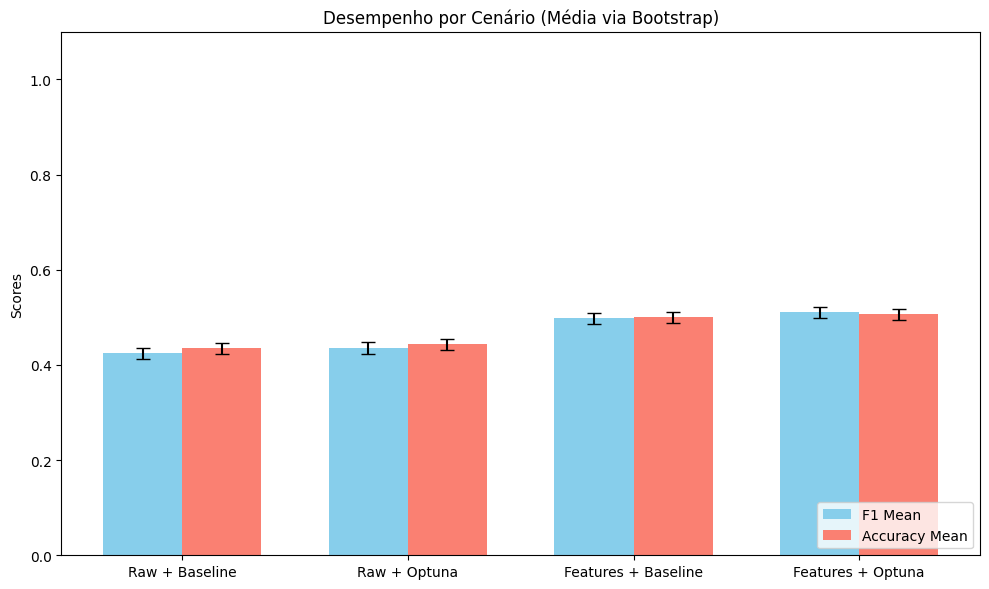

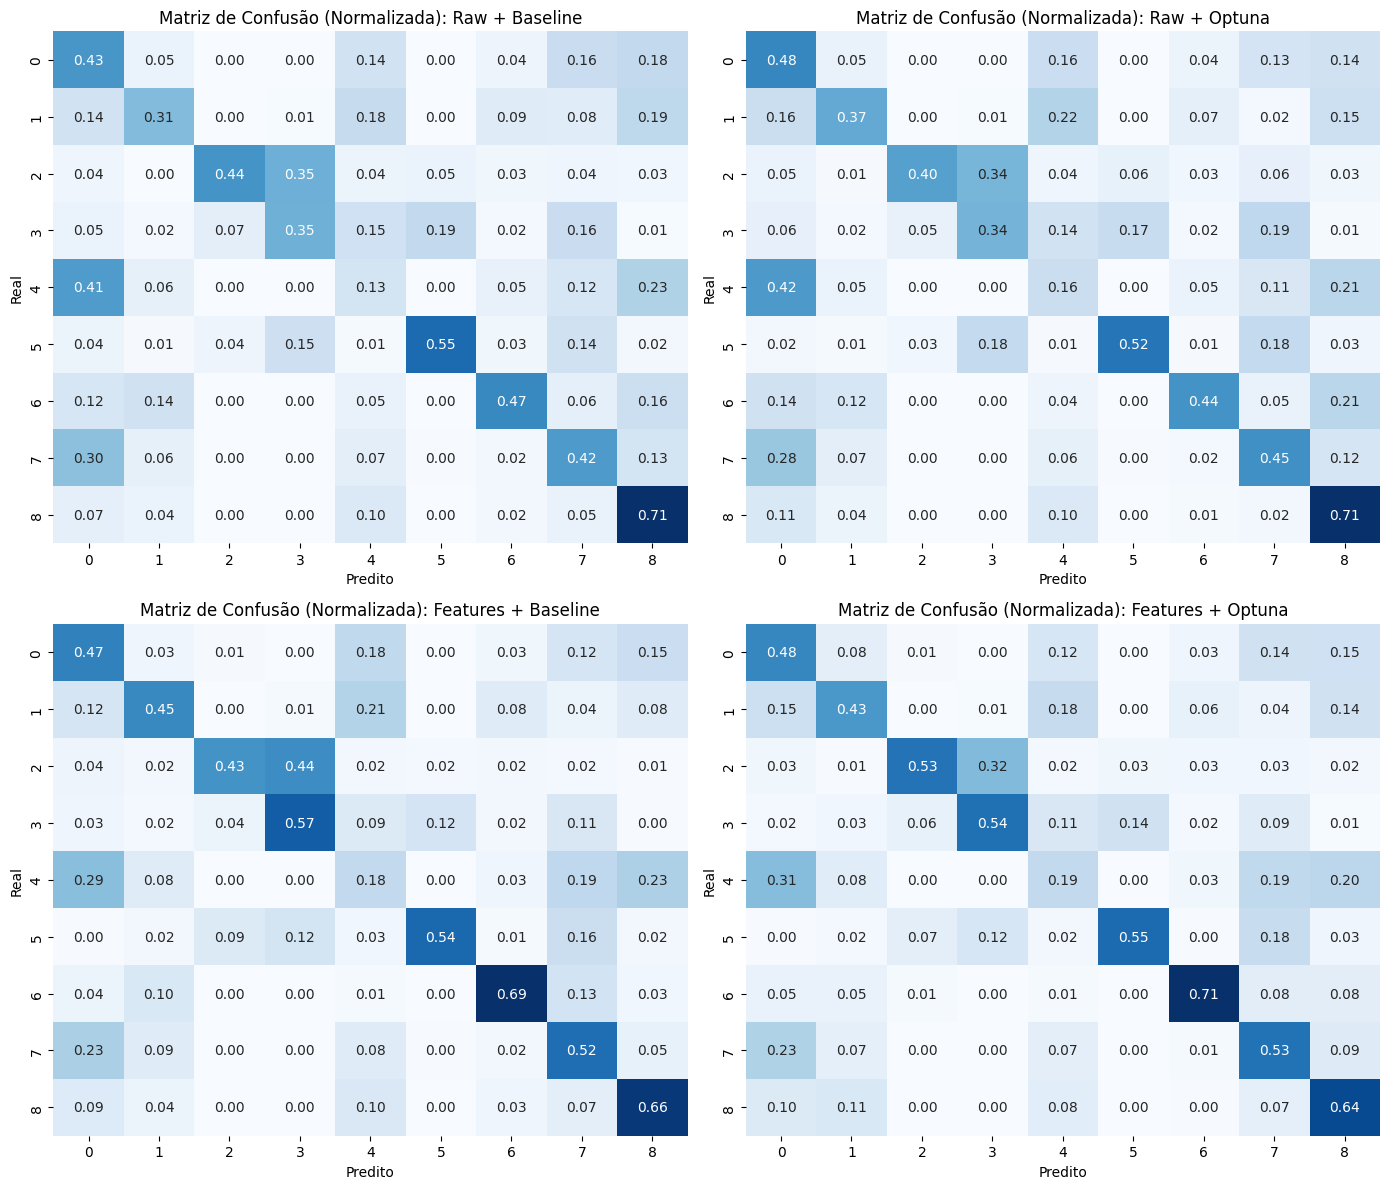

In [ ]:
# ==============================================================================
# 6. RESUMO E VISUALIZAÇÃO DOS RESULTADOS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n" + "="*70)
print("RESUMO FINAL DOS RESULTADOS (BOOTSTRAP)")
print("="*70)
df_resultados = pd.DataFrame(resultados)

if df_resultados.empty:
    print("AVISO: Nenhum resultado encontrado. O dataframe está vazio.")
    print("Verifique se os dados foram carregados corretamente na célula anterior.")
else:
    display(df_resultados)

    # ---------------------------------------------------------
    # PLOT 1: Histograma Comparativo de F1-Score e Accuracy
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    x = np.arange(len(df_resultados['Cenario']))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, df_resultados['F1 Mean'], width, label='F1 Mean', yerr=df_resultados['F1 Std'], capsize=5, color='skyblue')
    rects2 = ax.bar(x + width/2, df_resultados['Acc Mean'], width, label='Accuracy Mean', yerr=df_resultados['Acc Std'], capsize=5, color='salmon')

    ax.set_ylabel('Scores')
    ax.set_title('Desempenho por Cenário (Média via Bootstrap)')
    ax.set_xticks(x)
    ax.set_xticklabels(df_resultados['Cenario'])
    ax.legend(loc='lower right')
    ax.set_ylim([0, 1.1])

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # PLOT 2: Matrizes de Confusão
    # ---------------------------------------------------------
    if confusion_matrices:
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))
        axes = axes.flatten()

        for ax, (name, cm) in zip(axes, confusion_matrices.items()):
            sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax, cbar=False)
            ax.set_title(f'Matriz de Confusão (Normalizada): {name}')
            ax.set_xlabel('Predito')
            ax.set_ylabel('Real')

        plt.tight_layout()
        plt.show()